Read in cleaned COPD Dataset

In [28]:
import pandas as pd
csv_path = '/home/daniel.lien/dev/homework/data/cleaned_copd_data.csv'
df = pd.read_csv(csv_path)
df.shape

(143586, 13)

Filter For my Question of Interest COPD1_2

In [29]:
df = df[df['QuestionID'] == 'COPD1_2']
df.shape

(13200, 13)

In [30]:
df = df.drop(columns=[
            'Topic',
            'Question',
            'GeoLocation'
        ])
print(df.shape)

(13200, 10)


In [31]:
df.head()

,YearStart,LocationDesc,DataValueUnit,DataValueType,DataValue,StratificationCategory1,Stratification1,QuestionID,StratificationCategoryID1,StratificationID1
75,2016,Alaska,Number,Number,452.0,Overall,Overall,COPD1_2,OVERALL,OVR
76,2013,Alabama,Number,Number,5112.0,Overall,Overall,COPD1_2,OVERALL,OVR
77,2014,Alabama,"cases per 100,000",Age-adjusted Rate,304.4,Gender,Male,COPD1_2,GENDER,GENM
78,2017,Alabama,Number,Number,5248.0,Overall,Overall,COPD1_2,OVERALL,OVR
79,2010,Colorado,Number,Number,22.0,Race/Ethnicity,Asian or Pacific Islander,COPD1_2,RACE,API


In [32]:
# drop both Stratificaiton IDs
#combine stratification into one columne for grouping 
df = df.drop(columns=['StratificationCategoryID1', 'StratificationID1'])
df['StratificationCombined'] = df['StratificationCategory1'] + "_" + df['Stratification1']
df = df.drop(columns=['StratificationCategory1', 'Stratification1'])

In [33]:
# Only take Number 
df = df[df['DataValueType'] == 'Number']

In [34]:
df.head()

,YearStart,LocationDesc,DataValueUnit,DataValueType,DataValue,QuestionID,StratificationCombined
75,2016,Alaska,Number,Number,452.0,COPD1_2,Overall_Overall
76,2013,Alabama,Number,Number,5112.0,COPD1_2,Overall_Overall
78,2017,Alabama,Number,Number,5248.0,COPD1_2,Overall_Overall
79,2010,Colorado,Number,Number,22.0,COPD1_2,Race/Ethnicity_Asian or Pacific Islander
80,2013,Colorado,Number,Number,2279.0,COPD1_2,Gender_Male


In [35]:
df = df.dropna(subset=['DataValue'])

In [36]:
df.isnull().sum()

YearStart                 0
LocationDesc              0
DataValueUnit             0
DataValueType             0
DataValue                 0
QuestionID                0
StratificationCombined    0
dtype: int64

In [37]:
# save to csv
output_dir = '/home/daniel.lien/dev/homework/data/Single_Questions/COPD1_2.csv'
df.to_csv(output_dir, index=False)

EDA on COPD1_2


In [38]:
# Summary statistics for the 'DataValue' column
print(df['DataValue'].describe())

# Check the distribution of 'DataValueType'
print(df['DataValueType'].value_counts())

# Count unique values for 'YearStart', 'LocationDesc', and 'StratificationCombined'
print(df['YearStart'].value_counts())
print(df['LocationDesc'].value_counts())
print(df['StratificationCombined'].value_counts())

count     3425.000000
mean      2798.914453
std       3926.821722
min         20.000000
25%        201.000000
50%       1313.000000
75%       3780.000000
max      27611.000000
Name: DataValue, dtype: float64
DataValueType
Number    3425
Name: count, dtype: int64
YearStart
2020    324
2019    319
2017    317
2018    316
2015    314
2016    312
2014    310
2013    308
2012    304
2010    301
2011    300
Name: count, dtype: int64
LocationDesc
Michigan          88
California        88
Washington        88
Oregon            88
Texas             87
Florida           87
New York          87
Arizona           87
Colorado          85
North Carolina    85
Minnesota         82
Oklahoma          81
Nevada            80
Wisconsin         79
Ohio              79
Kansas            77
Pennsylvania      77
Illinois          77
New Jersey        77
Massachusetts     77
New Mexico        76
Virginia          76
Georgia           75
Maryland          75
Missouri          69
Indiana           66
Connecticu

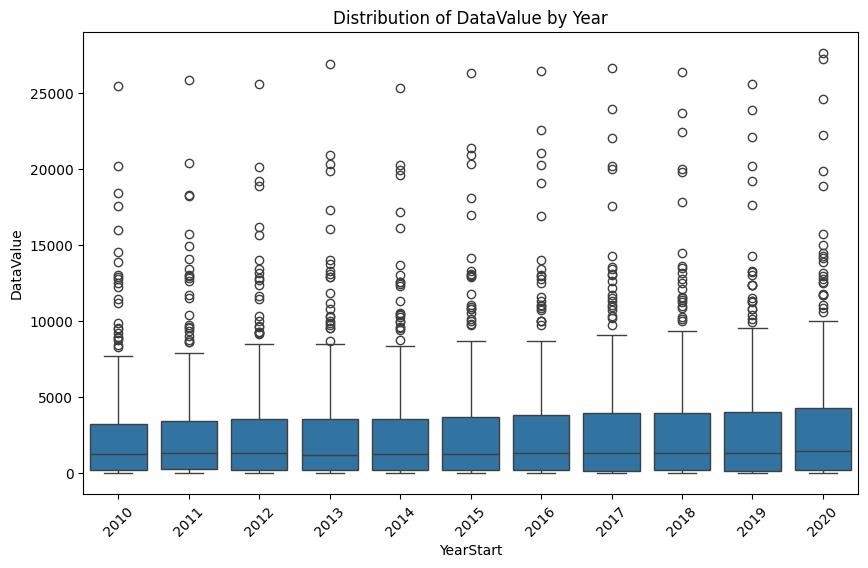

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot DataValue by YearStart
plt.figure(figsize=(10, 6))
sns.boxplot(x='YearStart', y='DataValue', data=df)
plt.title('Distribution of DataValue by Year')
plt.xticks(rotation=45)
plt.show()


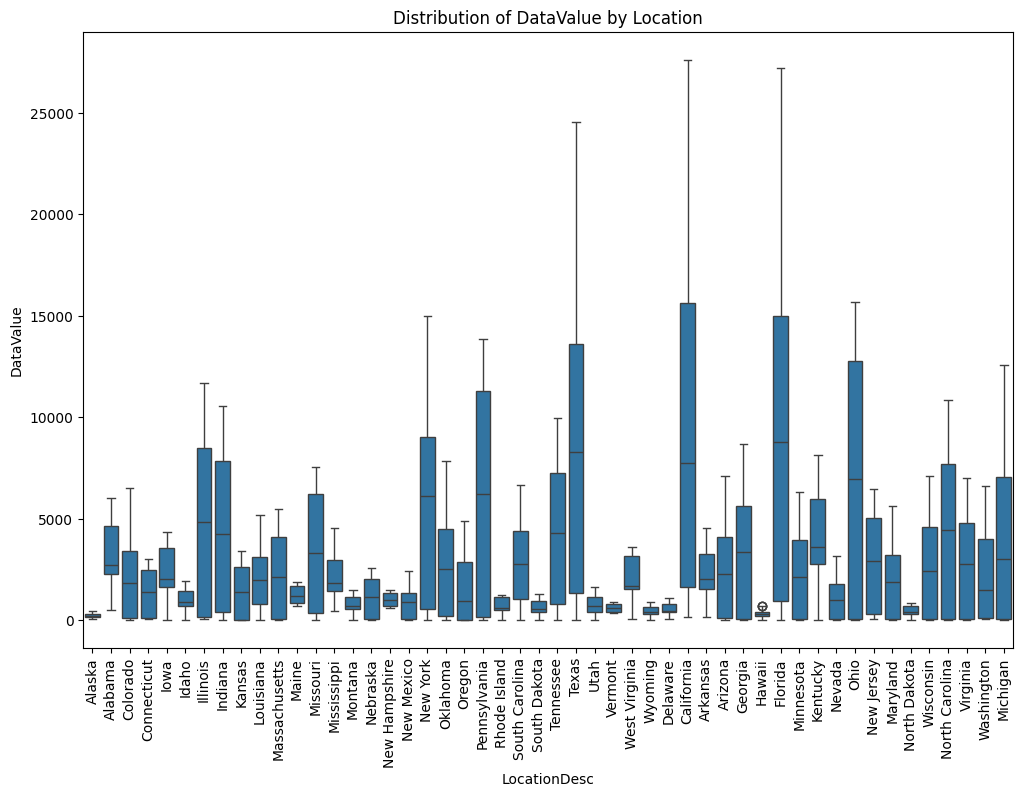

In [40]:
# Plot DataValue by LocationDesc
plt.figure(figsize=(12, 8))
sns.boxplot(x='LocationDesc', y='DataValue', data=df)
plt.title('Distribution of DataValue by Location')
plt.xticks(rotation=90)
plt.show()

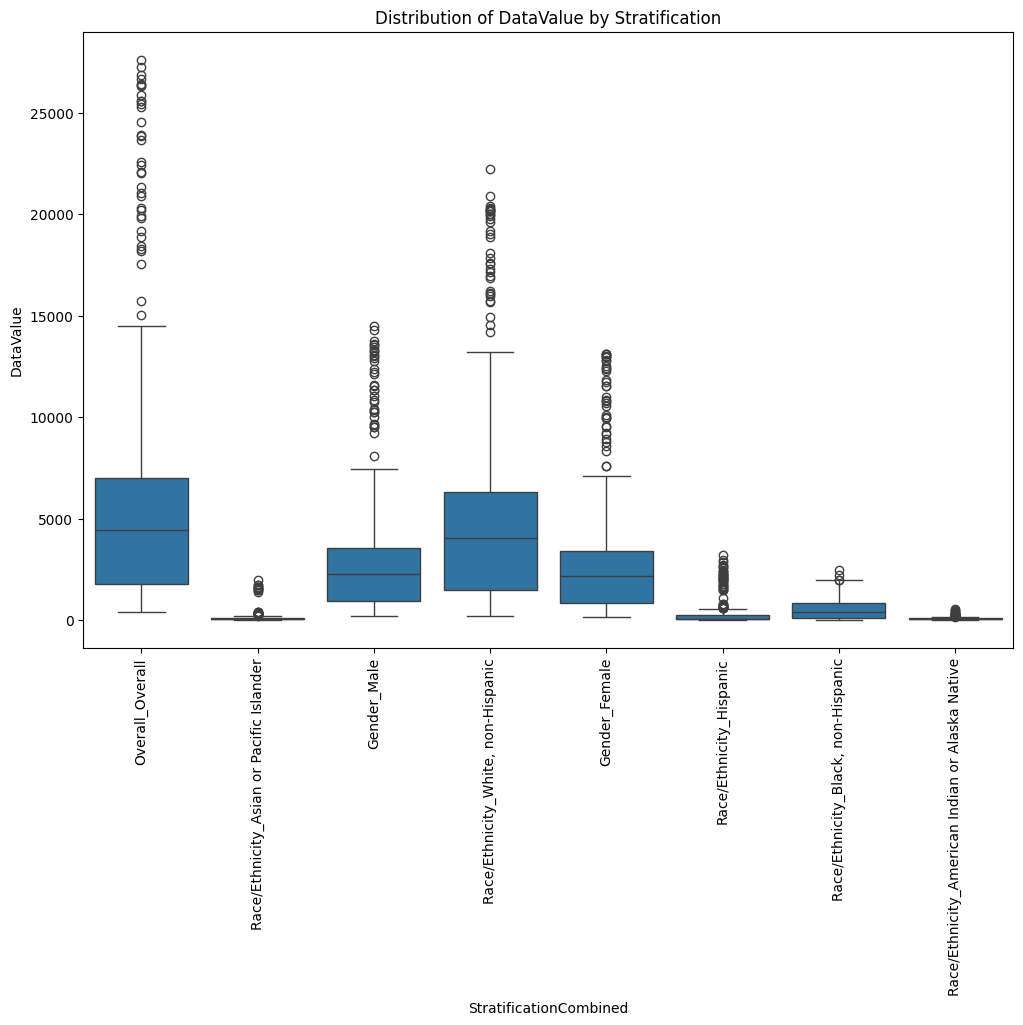

In [41]:
# Plot DataValue by StratificationCombined
plt.figure(figsize=(12, 8))
sns.boxplot(x='StratificationCombined', y='DataValue', data=df)
plt.title('Distribution of DataValue by Stratification')
plt.xticks(rotation=90)
plt.show()

In [42]:
# Filter for Gender and Race/Ethnicity stratifications in StratificationCombined
gender_data = df[df['StratificationCombined'].str.contains('Gender')]
race_ethnicity_data = df[df['StratificationCombined'].str.contains('Race/Ethnicity')]

# Check the distribution of gender and race/ethnicity stratifications
print(gender_data['StratificationCombined'].value_counts())
print(race_ethnicity_data['StratificationCombined'].value_counts())

StratificationCombined
Gender_Male      550
Gender_Female    550
Name: count, dtype: int64
StratificationCombined
Race/Ethnicity_White, non-Hispanic                 550
Race/Ethnicity_Black, non-Hispanic                 426
Race/Ethnicity_Hispanic                            351
Race/Ethnicity_Asian or Pacific Islander           234
Race/Ethnicity_American Indian or Alaska Native    214
Name: count, dtype: int64


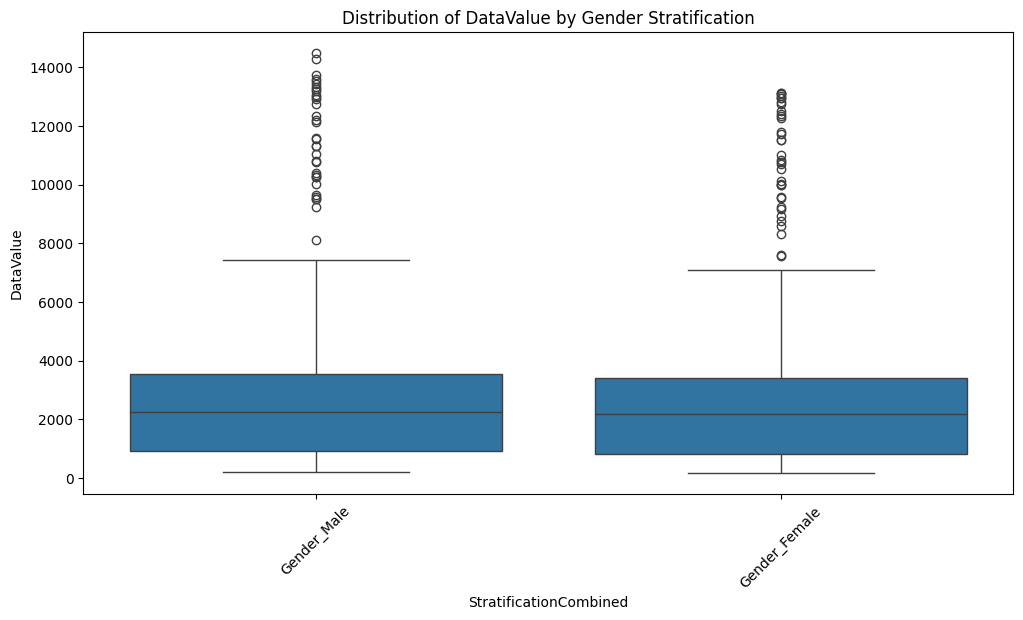

In [43]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='StratificationCombined', y='DataValue', data=gender_data)
plt.title('Distribution of DataValue by Gender Stratification')
plt.xticks(rotation=45)
plt.show()


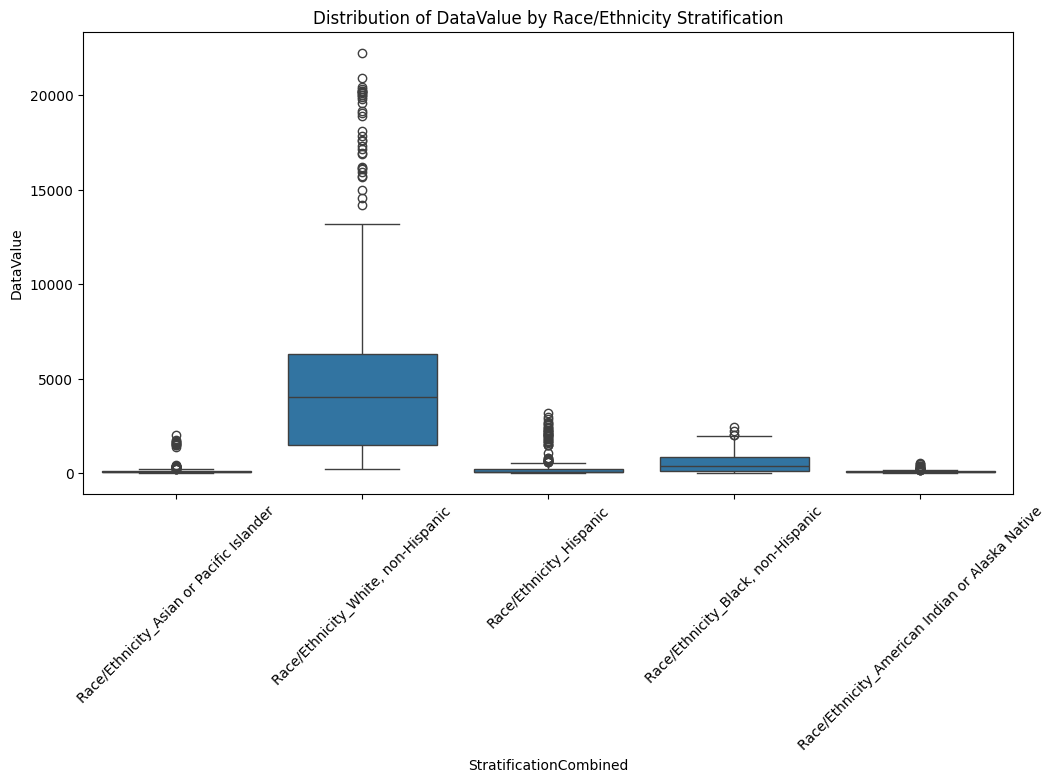

In [44]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='StratificationCombined', y='DataValue', data=race_ethnicity_data)
plt.title('Distribution of DataValue by Race/Ethnicity Stratification')
plt.xticks(rotation=45)
plt.show()
